# Auto ARIMA
## 1. 작업준비
### 1. 패키지 가져오기

In [1]:
from hossam import *

from matplotlib import pyplot as plt
from matplotlib import dates
import seaborn as sb
import numpy as np

from pandas import DatetimeIndex, DataFrame
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.3

✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


### 2. 데이터 가져오기


In [2]:
origin = load_data('air_passengers')
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print(origin.info())
origin.head()

어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


#### 1. DateTimeIndex 설정

In [3]:
df1 = origin.set_index('Month')
df1 = df1.asfreq('MS')
df1.index = DatetimeIndex(df1.index)
df1.sort_index(inplace=True)
df1.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 2. 훈련, 검증 데이터 분리

In [4]:
# 처음부터 70% 위치 전까지 분할
train = df1[: int(0.7 * len(df1))]
y_train = train['Passengers']
print(f'학습 데이터 개수: {len(train)}')

# 70% 위치부터 끝까지 분할
test = df1[int(0.7 * len(df1)) :]
y_test = test['Passengers']
print(f'학습 데이터 개수: {len(test)}')

학습 데이터 개수: 100
학습 데이터 개수: 44


### 3. 로그 변한(분산 안정화)

In [5]:
y_train_log = np.log(y_train)
display(y_train_log[:5])

y_test_log = np.log(y_test)
display(y_test_log[:5])


Month
1949-01-01   4.718
1949-02-01   4.771
1949-03-01   4.883
1949-04-01   4.860
1949-05-01   4.796
Freq: MS, Name: Passengers, dtype: float64

Month
1957-05-01   5.872
1957-06-01   6.045
1957-07-01   6.142
1957-08-01   6.146
1957-09-01   6.001
Freq: MS, Name: Passengers, dtype: float64

## 3. 분석 모형 구축
- 시계열 데이터를 ARIMA 모델에 맞추려고 할 때 첫 번째 목표는 측정항목을 최적화하는 ARIMA(p,d,q)(P,D,Q,s)값을 찾는 것
- 계절성을 의미하는 s값은 분서가가 판단하여 지정
- (p,d,q)(P,D,Q,)값은 분석가가 최소값과 최대값을 지정
- s값을 고정한 상태에서 0부터(p,d,q)(P,D,Q)로 주어진 값의 범위 안에서 최적의 값을 검색한다


In [ ]:
%%time

model = auto_arima(
    y=y_train_log,
    seasonal=True,              # 계절성 사용
    m=12,                       # 월별 데이터
    max_p=3,                    # 복잡도 상한
    max_q=3,
    max_P=1,
    max_Q=1,
    d=None,                     # 차분 자동
    D=None,                     # 계절 차분 자동
    information_criterion='bic' # 과적합 억제
)

print(model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  100
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 161.509
Date:                                  월, 23 2 2026   AIC                           -315.018
Time:                                      11:17:45   BIC                           -305.108
Sample:                                  01-01-1949   HQIC                          -311.025
                                       - 04-01-1957                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0414      0.012      3.586      0.000       0.019       0.064
ar.L1          0.68

## 4. 예상치 생성
### 1. 검증데이터에 대한 예측치

In [7]:
preds_log = model.predict(n_periods = len(y_test_log))
print(preds_log[:5])

# 로그 -> 원래 스케일 복원
preds = np.exp(preds_log)
print(preds[:5])

1957-05-01   5.867
1957-06-01   6.009
1957-07-01   6.125
1957-08-01   6.112
1957-09-01   5.994
Freq: MS, dtype: float64
1957-05-01   353.107
1957-06-01   407.261
1957-07-01   457.016
1957-08-01   451.261
1957-09-01   400.934
Freq: MS, dtype: float64


### 2. 성능평가지표

In [8]:
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, preds_log))
test_rmse = np.sqrt(mean_squared_error(y_test, preds))
print('Test RMSE(log):', test_rmse_log)
print('Test RMSE:', test_rmse)

Test RMSE(log): 0.12107738956084677
Test RMSE: 54.904956864300395


#### 인사이트
- 약 12.1%의 오차 존재

### 3. 관측치와 예상치 비교

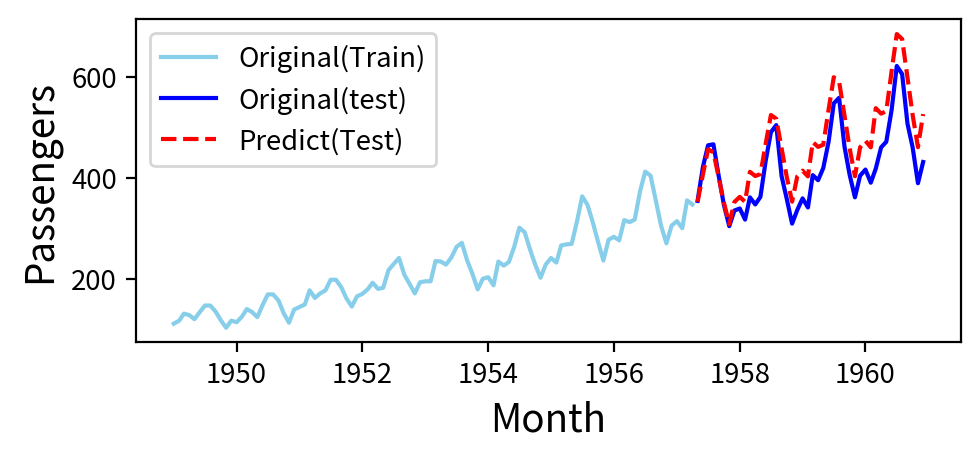

In [9]:
width_px = 1000
height_px = 480
rows = 1
cols = 1
figsize = (width_px/ my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize = figsize, dpi = my_dpi)

# 훈련 데이터 - 앞 70% 원본 데이터
sb.lineplot(data = train, x= train.index, y = 'Passengers',
           color = 'skyblue', label='Original(Train)')

# 검증 데이터 - 뒤 30%의 원본 데이터
sb.lineplot(data = test, x= test.index, y = 'Passengers',
           color = 'blue', label='Original(test)')

# 에측치 - 뒤 30%의 원본 데이터
sb.lineplot(x= preds.index, y = preds.values,
           color = 'red', label='Predict(Test)', linestyle='--')
# 그래프 꾸미기
ax.grid(True, alpha = 0.3) # 배경 격자 표시/숨김
ax.set_xlabel('Month')
ax.set_ylabel('Passengers')

# 출력
plt.grid()
plt.tight_layout()
plt.show()
plt.close()

## 5. 성능평가 - 잔차 플롯 검토

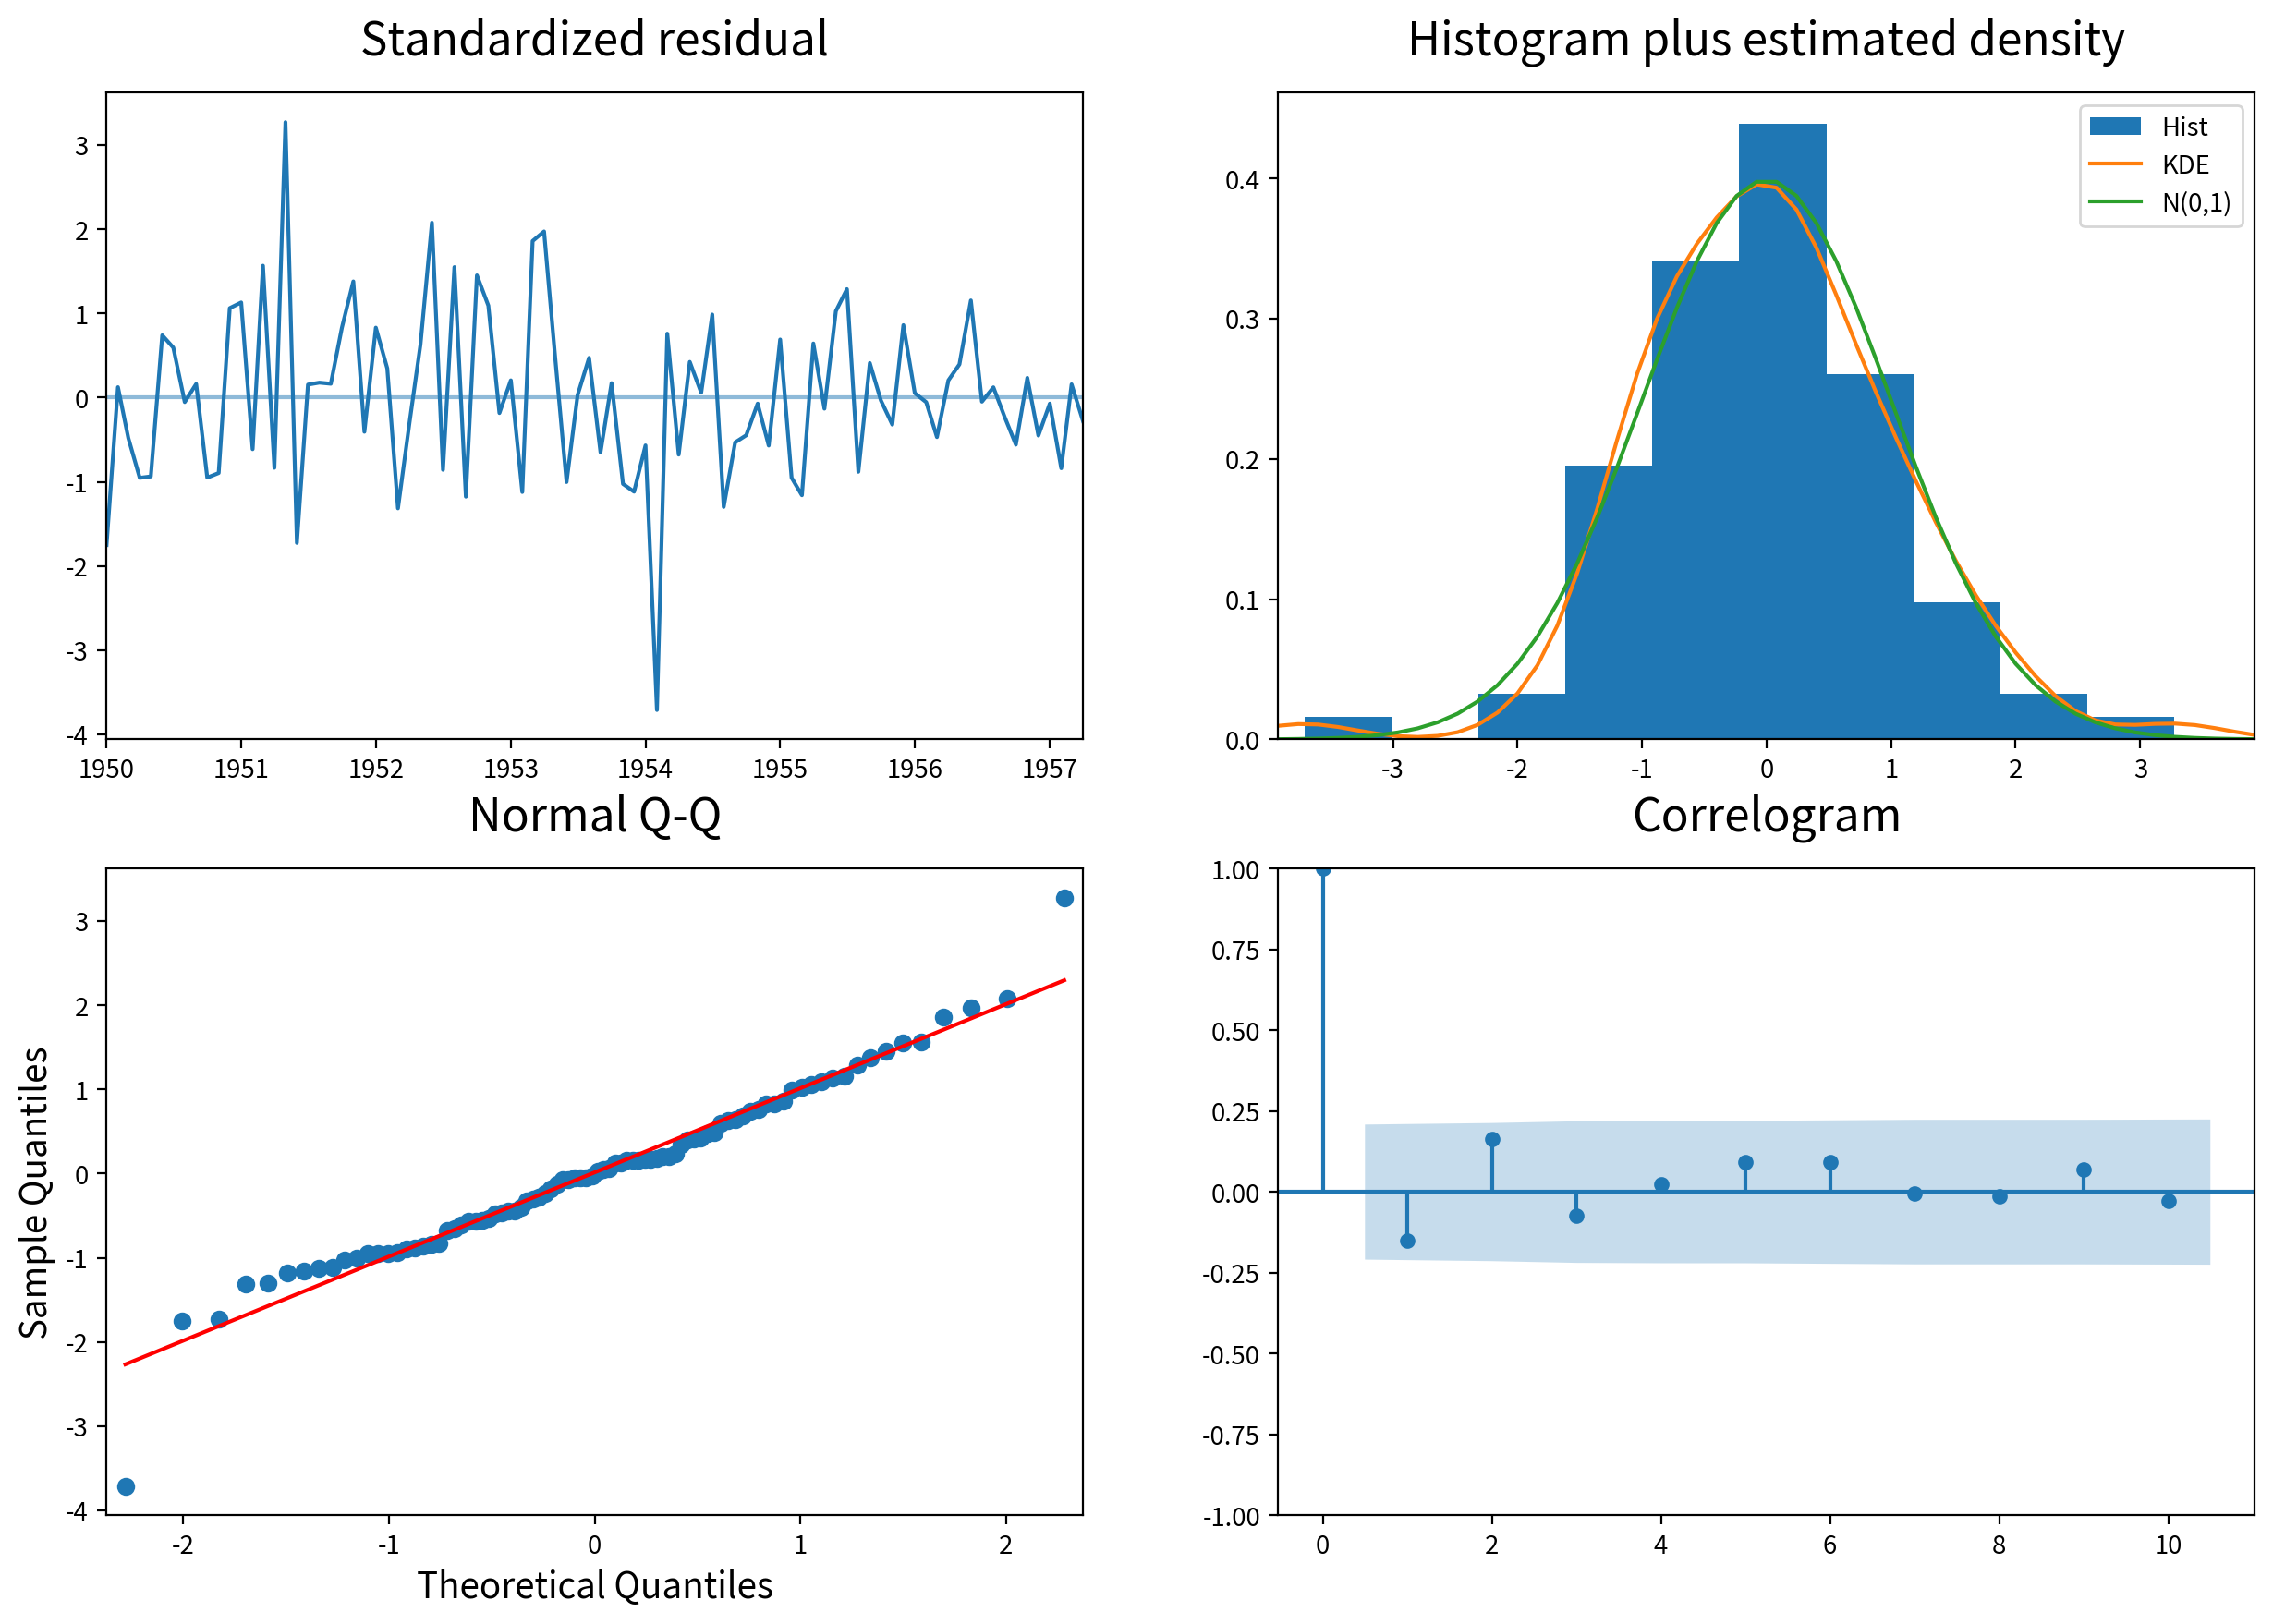

In [10]:
model.plot_diagnostics(figsize=(15,10))
plt.show()
plt.close()